In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2.2,style='white')
import pandas as pd
import numpy as np
import scipy
import pickle as pkl
from collections import OrderedDict 


In [2]:
latest_filename = '/data/permed/unified/dataframe/20210923/df_q_unified_pilot12_20210923.csv'
df = pd.read_csv(latest_filename, low_memory=False)

vaccine_labels = ['days_from_q_to_first', 'days_from_q_to_second', 'days_from_q_to_third']

days_after_vaccine = 14
days_before_vaccine = 7

q_dfs = [df[(df[vaccine_label]<=days_after_vaccine)&
            (df[vaccine_label]>=-days_before_vaccine)].copy()\
         .sort_values("quest_creation_timestamp")\
         .drop_duplicates(subset=['participant_num', vaccine_label], keep='last')\
         for vaccine_label in vaccine_labels]

df = pd.concat(q_dfs)

In [3]:
def get_heat_over_389_participants(df):
    test_df = df[pd.to_numeric(df.quest_heat, errors='coerce').notnull()]
    test_df['quest_heat_numeric'] = pd.to_numeric(test_df['quest_heat'])
    heat_over_389_rows = test_df.where(test_df['quest_heat_numeric'] > 38.9).where(test_df['quest_heat_numeric'] < 41).dropna(how='all')
    return list(heat_over_389_rows.index)


In [4]:
heat_over_389_participants = get_heat_over_389_participants(df)

for part in heat_over_389_participants:
    df.loc[part, "quest_symptoms"] = df.loc[part, "quest_symptoms"] + ',heat over 38.9'

<ipython-input-3-f77aac9f8aab>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['quest_heat_numeric'] = pd.to_numeric(test_df['quest_heat'])


In [5]:
df[['date','first_dose_date', 'second_dose_date', 'third_dose_date']].tail()

,date,first_dose_date,second_dose_date,third_dose_date
71234,2021-09-23 00:00:00,NaN,NaN,2021-09-18 12:37:00
93102,2021-09-23 00:00:00,2021-01-04 16:00:00,2021-01-25 16:00:00,2021-09-17 11:11:00
67318,2021-09-23 00:00:00,NaN,NaN,2021-09-23 12:35:00
61375,2021-09-23 00:00:00,NaN,NaN,2021-09-12 14:40:00
27174,2021-09-23 00:00:00,NaN,2021-02-18 19:02:00,2021-09-10 12:00:00


In [6]:
df[['days_from_q_to_first',
       'hours_from_q_to_first', 'days_from_q_to_second',
       'hours_from_q_to_second', 'days_from_q_to_third',
       'hours_from_q_to_third']].tail()

,days_from_q_to_first,hours_from_q_to_first,days_from_q_to_second,hours_from_q_to_second,days_from_q_to_third,hours_from_q_to_third
71234,NaN,NaN,NaN,NaN,4.0,116.392778
93102,261.0,6281.548056,240.0,5777.548056,5.0,142.364722
67318,NaN,NaN,NaN,NaN,-1.0,-2.948333
61375,NaN,NaN,NaN,NaN,10.0,260.436944
27174,NaN,NaN,216.0,5202.090278,13.0,313.123611


In [7]:
df[['quest_sleep_time', 'quest_sleep_quality',
       'quest_sport_time', 'quest_meetings', 'quest_mood', 'quest_stress',
       'quest_symptoms', 'quest_diagnosis', 'quest_other_symptoms',
       'quest_heat', 'quest_other_diagnosis']].tail()

,quest_sleep_time,quest_sleep_quality,quest_sport_time,quest_meetings,quest_mood,quest_stress,quest_symptoms,quest_diagnosis,quest_other_symptoms,quest_heat,quest_other_diagnosis
71234,5.0,1.0,180.0,3.0,1.0,-1.0,weakness,healthy,NaN,NaN,NaN
93102,7.0,1.0,30.0,10.0,1.0,-1.0,healthy,healthy,NaN,NaN,NaN
67318,4.0,0.0,10.0,11.0,0.0,0.0,healthy,healthy,NaN,NaN,NaN
61375,8.0,2.0,10.0,10.0,2.0,-1.0,healthy,healthy,NaN,NaN,NaN
27174,4.5,-1.0,30.0,15.0,-1.0,1.0,weakness,healthy,NaN,NaN,NaN


In [8]:
vaccines_to_analyze = ['days_from_q_to_first', 'days_from_q_to_second', 'days_from_q_to_third']

In [9]:
vaccine_labels = ['First Vaccination', 'Second Vaccination', 'Third Vaccination']

In [10]:
symptoms_dfs = [df[(df[v]<=14)&(df[v]>=-7)][['participant_num', 'quest_symptoms', v]] for v in vaccines_to_analyze]

In [11]:
for i in range(len(vaccine_labels)):
    print("%s n= %d" % (vaccine_labels[i], symptoms_dfs[i]["participant_num"].nunique()))

First Vaccination n= 261
Second Vaccination n= 395
Third Vaccination n= 1482


In [12]:
for symptoms_df in symptoms_dfs:
    symptoms_df["quest_symptoms_processed"] = symptoms_df["quest_symptoms"].replace({'-1': '',
                                                                             'skipped_question': '',
                                                                             np.nan: ''}, regex=True)

In [13]:
# Add helper methods and objects

#First, categorize heat and fever into > 38.9 and <= 38.9
#Severe: ['chest_pain', 'dyspnea', 'heat over 38.9', 'confusion', 'chills']
 
#Mild: everything else: ['abdominal_pain', 'feel_heat', 'heat_over_37.5', 'back_or_neck_pain', 'cold', 'muscles_pain', 'weakness', 'headache',
#'dizziness', 'vomiting', 'sore_throat', 'diarrhea', 'cough', 'hand_muscles_pain', 'leg_pain', 'ear_pain', 'taste_smell', 'lymph',
# 'fast_heartbeat', 'hypertension']


symp_titles = {'healthy':'No\n Reaction',
               'chest_pain': 'Chest\n Pain',
               'dyspnea':'Dyspnea',
               'heat over 38.9':'Fever\n >38.9',
               'confusion':'Confusion',
               'chills':'Chills',
               'abdominal_pain':'Muscle\n Pain',
               'feel_heat':'Fever\n <=38.9',
               'heat over 37.5':'Fever\n <=38.9',
               'back_or_neck_pain':'Muscle\n Pain',
               'cold':'Cold',
               'muscles_pain':'Muscle\n Pain',
               'weakness':'Fatigue',
               'headache':'Headache',
               'dizziness':'Dizziness',
               'vomiting':'Vomiting',
               'sore_throat':'Sore\n Throat',
               'diarrhea':'Diarrhea',
               'cough':'Cough',
               'hand_muscles_pain':'Muscle\n Pain',
               'leg_pain':'Muscle\n Pain',
               'ear_pain':'Muscle\n Pain',
               'taste_smell':'Loss of\nTaste/Smell',
               'lymph':'Lymph',
               'fast_heartbeat':'Fast Heartbeat',
               'hypertension':'Hypertension',
               'other':'Other',
              '' : 'Skipped Questionnaire'}

possible_symptoms = symp_titles.keys()

def classify_heat(heat_str):
    heat_array = heat_str.split(':')
    if heat_array[0] != 'heat':
        return ""
    try:
        temp = float(heat_array[1])
        # One person made a typo, heat is 636.6
        if temp >= 300:
            temp = temp - 600
        # A couple people did not report 30 with their heat, e.g. reporting 6.4 instead of 36.4
        if temp <= 10:
            temp = temp + 30
            
        if temp <= 30 or temp >= 41:
            return "error with heat %.2f" % (temp)
        
        if temp > 38.9:
            return "heat over 38.9"
        if temp > 37.5:
            return "heat over 37.5"
        else:# temp >= 35:
            return "no heat"
    # If the heat could not be converted to float, assume person is healthy
    except:
        return "no heat"

def preprocess_symptom_array(arr):
    arr = arr.copy()
    for i in range(len(arr)):
        s = arr[i]
        if "heat:" in s:
            arr[i] = classify_heat(s)
    return list(set(arr))

In [14]:
# Assert that all symptoms are accounted for in the symptoms listed
# in the above dictionary or by processing their heat entry

for symptoms_df in symptoms_dfs:
    for i,r in symptoms_df.iterrows():
        symptoms = r["quest_symptoms_processed"].split(',')
        for symptom in symptoms:
            #print(symptoms)
            assert((symptom in possible_symptoms)
                   or (classify_heat(symptom) in possible_symptoms)
                   or (classify_heat(symptom) == 'no heat'))

In [15]:
# Create baseline and make sure that those who reported symptoms
# in days [-7,...,-1] don't have the same symptom reported for day 0

def create_participant_to_symptoms_before_vaccine_dict(vaccine_num):
    days_since_vaccine = vaccines_to_analyze[vaccine_num]
    symptoms_df = symptoms_dfs[vaccine_num]
    
    part_to_symptoms_before_vaccine = dict()

    df = symptoms_df.where(symptoms_df[days_since_vaccine]<=-1).dropna(how='all')
    df = df.where(df["quest_symptoms_processed"] != '').dropna(how='all').drop_duplicates('participant_num', keep='last')

    for i,r in df.iterrows():
        symptoms_old = r["quest_symptoms_processed"].split(',')
        symptoms = preprocess_symptom_array(symptoms_old)


        participant = r["participant_num"]

        if symptoms == [''] or symptoms == ['skipped_question'] or symptoms == ['-1']:
            part_to_symptoms_before_vaccine[participant] = []
        elif 'healthy' in symptoms or symptoms == ['no heat']:
            part_to_symptoms_before_vaccine[participant] = []
        else:
            actual_symptoms = list()

            for s in symptoms:
                if s == 'no heat':
                    part_to_symptoms_before_vaccine[participant] = []
                    break
                elif s in possible_symptoms and s != '':
                    actual_symptoms.append(s)

            part_to_symptoms_before_vaccine[participant] = actual_symptoms

        print("Participant %s Symptoms %s => %s" % (participant, symptoms, part_to_symptoms_before_vaccine[participant]))
    return part_to_symptoms_before_vaccine

In [16]:
part_to_sbv_dicts = [create_participant_to_symptoms_before_vaccine_dict(i) for i in range(3)]

Participant p1_152 Symptoms ['healthy'] => []
Participant p1_3 Symptoms ['headache'] => ['headache']
Participant p1_23 Symptoms ['healthy'] => []
Participant 73 Symptoms ['healthy'] => []
Participant p1_296 Symptoms ['healthy'] => []
Participant p1_226 Symptoms ['healthy'] => []
Participant p1_123 Symptoms ['healthy'] => []
Participant p1_32 Symptoms ['other'] => ['other']
Participant 7 Symptoms ['other'] => ['other']
Participant p1_31 Symptoms ['healthy'] => []
Participant p1_28 Symptoms ['healthy'] => []
Participant p1_24 Symptoms ['healthy'] => []
Participant p1_132 Symptoms ['healthy'] => []
Participant 59 Symptoms ['healthy'] => []
Participant 83 Symptoms ['sore_throat'] => ['sore_throat']
Participant 115 Symptoms ['healthy'] => []
Participant 75 Symptoms ['healthy'] => []
Participant p1_22 Symptoms ['healthy'] => []
Participant p1_21 Symptoms ['healthy'] => []
Participant p1_6 Symptoms ['healthy'] => []
Participant p1_144 Symptoms ['healthy'] => []
Participant 57 Symptoms ['healt

Participant 681 Symptoms ['healthy'] => []
Participant 747 Symptoms ['healthy'] => []
Participant 76 Symptoms ['healthy'] => []
Participant 1400 Symptoms ['healthy'] => []
Participant 1281 Symptoms ['healthy'] => []
Participant 748 Symptoms ['healthy'] => []
Participant 574 Symptoms ['healthy'] => []
Participant 736 Symptoms ['healthy'] => []
Participant 662 Symptoms ['weakness'] => ['weakness']
Participant 448 Symptoms ['cold', 'weakness'] => ['cold', 'weakness']
Participant 1656 Symptoms ['healthy'] => []
Participant 564 Symptoms ['healthy'] => []
Participant 497 Symptoms ['healthy'] => []
Participant 1771 Symptoms ['healthy'] => []
Participant 441 Symptoms ['healthy'] => []
Participant 1271 Symptoms ['healthy'] => []
Participant 276 Symptoms ['healthy'] => []
Participant 891 Symptoms ['healthy'] => []
Participant 1505 Symptoms ['healthy'] => []
Participant 6 Symptoms ['healthy'] => []
Participant 689 Symptoms ['healthy'] => []
Participant 1233 Symptoms ['weakness'] => ['weakness']
P

Participant 99 Symptoms ['healthy'] => []
Participant 2023 Symptoms ['healthy'] => []
Participant 2021 Symptoms ['healthy'] => []
Participant 2560 Symptoms ['healthy'] => []
Participant 827 Symptoms ['healthy'] => []
Participant 1832 Symptoms ['healthy'] => []
Participant 2585 Symptoms ['healthy'] => []
Participant 2800 Symptoms ['healthy'] => []
Participant 2540 Symptoms ['healthy'] => []
Participant 1655 Symptoms ['diarrhea'] => ['diarrhea']
Participant 1154 Symptoms ['healthy'] => []
Participant 470 Symptoms ['healthy'] => []
Participant 2445 Symptoms ['healthy'] => []
Participant 236 Symptoms ['healthy'] => []
Participant 1873 Symptoms ['healthy'] => []
Participant 2483 Symptoms ['cold'] => ['cold']
Participant 151 Symptoms ['healthy'] => []
Participant 238 Symptoms ['healthy'] => []
Participant 832 Symptoms ['healthy'] => []
Participant 2643 Symptoms ['sore_throat', 'cold'] => ['sore_throat', 'cold']
Participant 1898 Symptoms ['healthy'] => []
Participant 1567 Symptoms ['healthy']

Participant 2444 Symptoms ['healthy'] => []
Participant 2053 Symptoms ['cough', 'cold', 'weakness'] => ['cough', 'cold', 'weakness']
Participant 1423 Symptoms ['healthy'] => []
Participant 2436 Symptoms ['healthy'] => []
Participant 1700 Symptoms ['healthy'] => []
Participant 1892 Symptoms ['healthy'] => []
Participant 2579 Symptoms ['healthy'] => []
Participant 4406 Symptoms ['healthy'] => []
Participant 2457 Symptoms ['healthy'] => []
Participant 1531 Symptoms ['healthy'] => []
Participant 1240 Symptoms ['abdominal_pain'] => ['abdominal_pain']
Participant 1449 Symptoms ['healthy'] => []
Participant 1431 Symptoms ['healthy'] => []
Participant 221 Symptoms ['healthy'] => []
Participant 2508 Symptoms ['healthy'] => []
Participant 2240 Symptoms ['healthy'] => []
Participant 1502 Symptoms ['weakness'] => ['weakness']
Participant 2459 Symptoms ['healthy'] => []
Participant 2852 Symptoms ['healthy'] => []
Participant 1887 Symptoms ['healthy'] => []
Participant 2651 Symptoms ['healthy'] => [

In [17]:
for part_to_sbv_dict in part_to_sbv_dicts:
    print(len(part_to_sbv_dict.keys()))

216
343
1327


In [18]:
severe_symptoms = ['chest_pain', 'dyspnea', 'heat over 38.9', 'confusion', 'chills']

In [19]:
with open('v3_participant_nums.pkl', 'rb') as f:
    v3_participant_nums = pkl.load(f)
        

In [20]:
severe_parts = v3_participant_nums[0]

In [21]:
df_3 = symptoms_dfs[2]

In [22]:
severe_df = df_3[df_3['participant_num'].isin(severe_parts)]

In [23]:
def beta(value,n):
    lower = scipy.stats.beta.ppf(0.025, value, n-value + 1, loc=0, scale=1)
    upper = scipy.stats.beta.ppf(0.975, value + 1, n-value, loc=0, scale=1)
    lower = (value/n) - lower
    #print(value/n)
    upper = upper - (value/n)
    if lower < 0 or value == 0:
        lower = 0
    return [lower,upper]

In [24]:
# Get Healthy and Sick Participant Numbers

def get_number_of_severe_symptoms(day_since_vaccine):
    severe_symptoms_count = 0
    days_since_vaccine = 'days_from_q_to_third'
    part_to_symptoms_before_vaccine = part_to_sbv_dicts[2]
    

    df = severe_df[severe_df[days_since_vaccine] == day_since_vaccine]

    for i,r in df.iterrows():
        
        symptoms_old = r["quest_symptoms_processed"].split(',')
        symptoms = preprocess_symptom_array(symptoms_old)

        participant = r["participant_num"]
        has_severe_symptoms = False
        
        # If they don't have data from the day before the vaccine, we won't be able to tell
        # if their symptoms are new from the vaccine or not.
        # I exclude healthy people who did not fill out the form the day before the vaccine
        # as to not bias the findings to include those who were healthy.
        try:
            symptoms_before_vaccine = part_to_symptoms_before_vaccine[participant]

            if symptoms == [''] or symptoms == ['skipped_question'] or symptoms == ['-1']:
                # Participants who skipped the questionnaire after the vaccine get skipped.
                pass
            elif 'healthy' in symptoms or symptoms == ['no heat']:
                # Healthy participants just get added to all_participants
                pass
            else:
                # Iterate through all of the symptoms and classify the new ones into
                # Severe and Mild reactions.
                for s in symptoms:
                    if s in possible_symptoms and s != '' and s != 'no heat':
                        if s not in symptoms_before_vaccine:
                            if s in severe_symptoms:
                                has_severe_symptoms = True
        except:
            pass
        
        if has_severe_symptoms:
            severe_symptoms_count += 1
            #print(r)
            
    val = severe_symptoms_count
    n = len(df.index)
    b = beta(val, n)
    print(b)
    return val, n, val/n, b

In [25]:
vals = list()
ns = list()
proportions = list()
betas = list()

for i in range(14):
    val, n, prop, b = get_number_of_severe_symptoms(i)
    vals.append(val)
    ns.append(n)
    proportions.append(prop)
    betas.append(b)

[0.1046852468903986, 0.09167537981145013]
[0.10896702817478376, 0.09331815517540265]
[0.0979134005771709, 0.1169687576981514]
[0.03653276731350759, 0.08285743374441273]
[0.04477505472577202, 0.1000256885874694]
[0.01874400681527715, 0.08332277542134851]
[0.017721600333022485, 0.07900919756743519]
[0.04394878117561423, 0.09832947823607777]
[0.027878049249612943, 0.0782733416628486]
[0.042384457737254064, 0.09510302237576254]
[0.029270708691239836, 0.08194771108591836]
[0, 0.06266748091448496]
[0.017721600333022485, 0.07900919756743519]
[0.04179922278353763, 0.11402291207260634]


In [26]:
palette = sns.color_palette('tab10')[9]

In [27]:
betas

[[0.1046852468903986, 0.09167537981145013],
 [0.10896702817478376, 0.09331815517540265],
 [0.0979134005771709, 0.1169687576981514],
 [0.03653276731350759, 0.08285743374441273],
 [0.04477505472577202, 0.1000256885874694],
 [0.01874400681527715, 0.08332277542134851],
 [0.017721600333022485, 0.07900919756743519],
 [0.04394878117561423, 0.09832947823607777],
 [0.027878049249612943, 0.0782733416628486],
 [0.042384457737254064, 0.09510302237576254],
 [0.029270708691239836, 0.08194771108591836],
 [0, 0.06266748091448496],
 [0.017721600333022485, 0.07900919756743519],
 [0.04179922278353763, 0.11402291207260634]]

In [28]:
np.array(betas)*100

array([[10.46852469,  9.16753798],
       [10.89670282,  9.33181552],
       [ 9.79134006, 11.69687577],
       [ 3.65327673,  8.28574337],
       [ 4.47750547, 10.00256886],
       [ 1.87440068,  8.33227754],
       [ 1.77216003,  7.90091976],
       [ 4.39487812,  9.83294782],
       [ 2.78780492,  7.82733417],
       [ 4.23844577,  9.51030224],
       [ 2.92707087,  8.19477111],
       [ 0.        ,  6.26674809],
       [ 1.77216003,  7.90091976],
       [ 4.17992228, 11.40229121]])

In [29]:
np.array(proportions)*100

array([69.56521739, 71.42857143, 27.39726027,  4.61538462,  5.66037736,
        1.92307692,  1.81818182,  5.55555556,  3.17460317,  5.35714286,
        3.33333333,  0.        ,  1.81818182,  4.76190476])

In [31]:
for i in range(len(proportions)):
    print(proportions[i] - betas[i][0], proportions[i] + betas[i][1])

0.5909669270226449 0.7873275537244936
0.6053186861109305 0.807603869461117
0.1760592021625551 0.3909413604378774
0.009621078840338568 0.1290112798982589
0.011828718859133641 0.15662946217237506
0.0004867624154920834 0.10255354465211775
0.0004602178487956958 0.09719101574925337
0.011606774379941322 0.15388503379163332
0.003867982496418801 0.11001937340888035
0.011186970834174505 0.14867445094719112
0.004062624642093497 0.11528104441925169
0.0 0.06266748091448496
0.0004602178487956958 0.09719101574925337
0.005819824835509989 0.16164195969165396


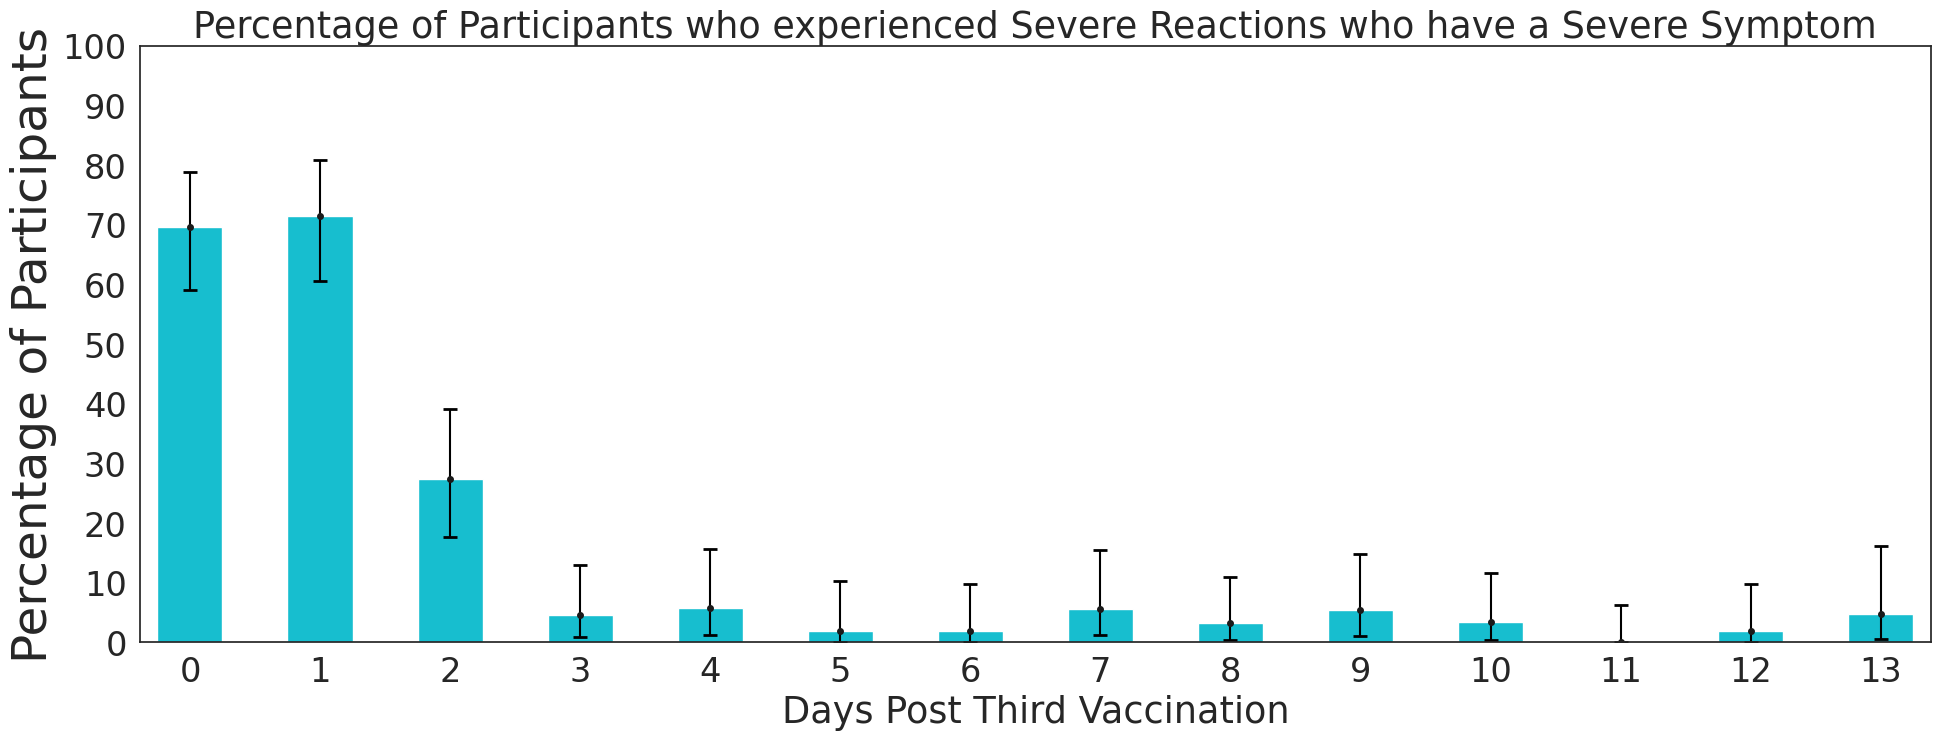

In [30]:
labels = np.arange(14)
vals = np.array(proportions) * 100
errs = 100*np.array(betas).T

x = np.arange(14)  # the label locations
width = 1  # the width of the bars

fig, ax = plt.subplots(figsize=(20,8))
rects3 = ax.bar(x, vals, width/2, color = palette)
plt.errorbar(x, vals, yerr=errs, capsize=5, markeredgewidth=2, fmt='.k',ecolor='black')
ax.set_ylabel('Percentage of Participants', fontsize=35)
ax.set_xticks(x)

#ax.legend(prop={'size': 30},title = 'Days Post Third Vaccination', frameon=False)
plt.margins(y=0,x=0.01)
ax.set_yticks(range(0,105,10))

plt.title("Percentage of Participants who experienced Severe Reactions who have a Severe Symptom")
ax.set_xlabel("Days Post Third Vaccination")

fig.tight_layout()

plt.show()

# 1 here is the day of vaccination